# Meta-learning paper plots with MAML transformer overlays

This notebook leaves `MetaPaperPlotsPerTask.ipynb` untouched. It reuses the already-computed ICL transformer and baseline curves from cache, then computes only the meta-learning transformer curve for each task and overlays it on the same per-task plot.


In [9]:
import ast
import json
import os
import sys
from pathlib import Path

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().resolve().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.environ.setdefault("HF_HOME", "/mnt/nlp/scratch/home/mpanwar/.cache/huggingface/hf-home")


'/mnt/nlp/scratch/home/mpanwar/.cache/huggingface/hf-home'

In [10]:
import importlib

import base_models as base_models_module
import eval as eval_module
import meta_eval as meta_eval_module
import models as models_module
import plot_meta_paper_figure as meta_plots

# Reload local modules so notebook reruns pick up source edits without restarting the kernel.
meta_eval_module = importlib.reload(meta_eval_module)
eval_module = importlib.reload(eval_module)
base_models_module = importlib.reload(base_models_module)
models_module = importlib.reload(models_module)
meta_plots = importlib.reload(meta_plots)

from eval import get_model_from_run
from plot_meta_paper_figure import (
    TASK_SPECS,
    find_latest_run,
    get_error_normalization,
    get_task_metrics,
    plot_task,
    rename_model,
)

task_metrics = {}
figures = {}


## Evaluation notes

The ICL transformer and baseline curves are not recomputed here. They are loaded from cached metrics for the original ICL runs; if a task was plotted in the source notebook without a `metrics.json` cache, this notebook falls back to the metric dictionary stored in that notebook's output.

The meta-learning curve uses the same task, data distribution, dimensionality, prompt-length axis, squared-error metric, bootstrap aggregation, and normalization as the ICL plot. The only intentional difference is the model-evaluation rule: the meta-learning transformer uses the `maml` eval defined in `src/eval.py`, which adapts the model with one or more inner-loop gradient steps on the first `k` examples and measures the query loss at point `k`. This is the meta-learning counterpart of the ICL curve, where the ICL transformer conditions on the first `k` examples directly in the prompt.


In [11]:
ICL_EVAL_NAME = "standard"
MAML_EVAL_NAME = "maml"

# ICL/baseline curves are cache-only in this notebook.
ICL_CACHE_ONLY = True

# Meta curves are computed if the `maml` eval is missing, and then cached in each meta run's metrics.json.
MAML_USE_CACHE = True

LINEAR_MAML_RUN = "1541c24b-e0c6-4c29-9dfe-49ff15e6e437"
SPARSE_MAML_RUN = "8c5cff2f-cd47-4a9c-8228-afdb9596826b"
TREE_MAML_RUN = "032c4021-c5c7-49e8-b00d-4f9dd6ea898b"
RELU_MAML_RUN = "a6e7479c-0345-44bf-97a3-ceeabfb48dc9"

LINEAR_ICL_RUN = "12cc04e3-c831-488a-ac34-0d8388192559"
SPARSE_ICL_RUN = "1bbcaa69-fe39-4335-abb2-28172861bf5a"
TREE_ICL_RUN = "3cf4987d-48cd-407f-b874-a882c49e9331"
RELU_ICL_RUN = "9f5157b6-5ca2-420d-a9fe-4dd30d619dda"

RUN_ROOTS = {
    "maml": {
        "linear_regression": REPO_ROOT / "models" / "meta_linear_regression",
        "sparse_linear_regression": REPO_ROOT / "models" / "meta_sparse_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "meta_decision_tree",
        "relu_2nn_regression": REPO_ROOT / "models" / "meta_relu_2nn_regression",
    },
    "icl": {
        "linear_regression": REPO_ROOT / "models" / "linear_regression",
        "sparse_linear_regression": REPO_ROOT / "models" / "sparse_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "decision_tree",
        "relu_2nn_regression": REPO_ROOT / "models" / "relu_2nn_regression",
    },
}

RUN_OVERRIDES = {
    "maml": {
        "linear_regression": LINEAR_MAML_RUN,
        "sparse_linear_regression": SPARSE_MAML_RUN,
        "decision_tree": TREE_MAML_RUN,
        "relu_2nn_regression": RELU_MAML_RUN,
    },
    "icl": {
        "linear_regression": LINEAR_ICL_RUN,
        "sparse_linear_regression": SPARSE_ICL_RUN,
        "decision_tree": TREE_ICL_RUN,
        "relu_2nn_regression": RELU_ICL_RUN,
    },
}

run_paths = {"maml": {}, "icl": {}}
for family in ["maml", "icl"]:
    for task_name in [
        "linear_regression",
        "sparse_linear_regression",
        "decision_tree",
        "relu_2nn_regression",
    ]:
        override = RUN_OVERRIDES[family][task_name]
        if override is not None:
            run_path = Path(override)
            if not run_path.is_absolute():
                run_path = RUN_ROOTS[family][task_name] / run_path
        else:
            run_path = find_latest_run(RUN_ROOTS[family][task_name])
        run_paths[family][task_name] = run_path

run_paths


{'maml': {'linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/1541c24b-e0c6-4c29-9dfe-49ff15e6e437'),
  'sparse_linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_sparse_linear_regression/8c5cff2f-cd47-4a9c-8228-afdb9596826b'),
  'decision_tree': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/032c4021-c5c7-49e8-b00d-4f9dd6ea898b'),
  'relu_2nn_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_relu_2nn_regression/a6e7479c-0345-44bf-97a3-ceeabfb48dc9')},
 'icl': {'linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559'),
  'sparse_linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/sparse_linear_regression/1bbcaa69-fe39-4335-abb2-28172861bf5a'),
  'decision_tree': PosixPath('/mnt/nlp/scratch/home/

In [12]:
MODEL_ORDERS = {
    "linear_regression": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "Least Squares",
        "3-Nearest Neighbors",
        "Averaging",
    ],
    "sparse_linear_regression": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "Least Squares",
        "Averaging",
        "Lasso (alpha=0.01)",
    ],
    "decision_tree": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "3-Nearest Neighbors",
        "Greedy Tree Learning",
        "XGBoost",
        "Greedy Tree Learning\n(w/ sign preproc.)",
        "XGBoost\n(w/ sign preproc.)",
    ],
    "relu_2nn_regression": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "Least Squares",
        "3-Nearest Neighbors",
        "2-layer NN, GD",
    ],
}

# The source notebook's plotted return values are used only when a run was plotted with USE_CACHE=False.
SOURCE_NOTEBOOK = REPO_ROOT / "EvalNotebooks" / "MetaPaperPlotsPerTask.ipynb"
SOURCE_OUTPUT_CELLS = {
    "linear_regression": 9,
    "sparse_linear_regression": 11,
    "decision_tree": 13,
    "relu_2nn_regression": 15,
}

# Match the ICL run's evaluation batch size; this affects batching, not the task distribution.
MAML_EVAL_OVERRIDES = {
    "linear_regression": {"batch_size": 64},
    "sparse_linear_regression": {"batch_size": 64},
    "decision_tree": {"batch_size": 64},
    "relu_2nn_regression": {"batch_size": 64},
}


In [13]:
def _normalize_and_rename_cached_eval(raw_eval_metrics, run_path, transformer_label):
    _, conf = get_model_from_run(str(run_path), only_conf=True)
    normalization = get_error_normalization(conf)
    renamed = {}
    for model_name, model_metrics in raw_eval_metrics.items():
        renamed_model = rename_model(model_name, conf, transformer_label=transformer_label)
        renamed[renamed_model] = {
            key: [value / normalization for value in values]
            for key, values in model_metrics.items()
        }
    return renamed


def _extract_metrics_from_source_notebook(task_name):
    nb = json.loads(SOURCE_NOTEBOOK.read_text())
    cell = nb["cells"][SOURCE_OUTPUT_CELLS[task_name]]
    for output in cell.get("outputs", []):
        text = "".join(output.get("data", {}).get("text/plain", []))
        stripped = text.strip()
        figure_idx = stripped.rfind("<Figure")
        if stripped.startswith("({") and figure_idx != -1:
            metrics_text = stripped[1:figure_idx].rstrip()
            if metrics_text.endswith(","):
                metrics_text = metrics_text[:-1].rstrip()
            return ast.literal_eval(metrics_text)
    raise FileNotFoundError(
        f"No cached execute_result metrics found for {task_name} in {SOURCE_NOTEBOOK}"
    )


def load_cached_icl_metrics(task_name):
    icl_run = run_paths["icl"][task_name]
    metrics_path = icl_run / "metrics.json"
    required_models = set(MODEL_ORDERS[task_name]) - {"Transformer (MAML)"}

    if metrics_path.exists():
        with metrics_path.open() as fp:
            all_metrics = json.load(fp)
        if ICL_EVAL_NAME in all_metrics:
            metrics = _normalize_and_rename_cached_eval(
                all_metrics[ICL_EVAL_NAME],
                icl_run,
                transformer_label="Transformer (ICL)",
            )
            if required_models.issubset(metrics.keys()):
                print(f"  loaded cached ICL/baseline curves: {metrics_path}", flush=True)
                return {name: metrics[name] for name in MODEL_ORDERS[task_name] if name in metrics}
            missing = sorted(required_models - set(metrics.keys()))
            print(f"  metrics.json is missing plotted curves {missing}; falling back to source notebook output", flush=True)

    if ICL_CACHE_ONLY:
        metrics = _extract_metrics_from_source_notebook(task_name)
        print(f"  loaded cached ICL/baseline curves from source notebook output: {SOURCE_NOTEBOOK.name}", flush=True)
        return {name: metrics[name] for name in MODEL_ORDERS[task_name] if name in metrics}

    raise FileNotFoundError(f"No cache available for {task_name}: {metrics_path}")


def compute_maml_metrics(task_name):
    maml_run = run_paths["maml"][task_name]
    overrides = MAML_EVAL_OVERRIDES.get(task_name)
    print(f"  computing/loading meta-learning curve: {maml_run}", flush=True)
    if overrides:
        print(f"  MAML eval overrides: {overrides}", flush=True)

    return get_task_metrics(
        maml_run,
        MAML_EVAL_NAME,
        cache=MAML_USE_CACHE,
        transformer_label="Transformer (MAML)",
        skip_baselines=True,
        eval_kwargs_overrides=overrides,
    )


def compute_and_plot_task_with_maml(task_name):
    task_title = TASK_SPECS[task_name]["title"]
    print("\n" + "=" * 80, flush=True)
    print(f"Task: {task_title} [{task_name}]", flush=True)
    print("ICL transformer and baselines: cache only", flush=True)
    print("Meta-learning transformer: MAML eval, baselines skipped", flush=True)

    cached_icl_metrics = load_cached_icl_metrics(task_name)
    maml_metrics = compute_maml_metrics(task_name)

    combined = {}
    combined.update(cached_icl_metrics)
    combined.update(maml_metrics)
    task_metrics[task_name] = combined
    print(f"  curves available: {sorted(combined.keys())}", flush=True)

    fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.0), constrained_layout=True)
    plot_task(ax, task_name, combined, model_order=MODEL_ORDERS[task_name])
    figures[task_name] = fig
    display(fig)
    plt.close(fig)
    return combined, fig


In [14]:
# Sanity check: the ICL and meta runs match on task family, data distribution,
# dimensionality, prompt length, and task kwargs. Batch size is overridden above for MAML eval.
for task_name in MODEL_ORDERS:
    _, icl_conf = get_model_from_run(str(run_paths["icl"][task_name]), only_conf=True)
    _, maml_conf = get_model_from_run(str(run_paths["maml"][task_name]), only_conf=True)
    checks = {
        "task": icl_conf.training.task == maml_conf.training.task,
        "data": icl_conf.training.data == maml_conf.training.data,
        "n_dims": icl_conf.model.n_dims == maml_conf.model.n_dims,
        "n_points": icl_conf.training.curriculum.points.end == maml_conf.training.curriculum.points.end,
        "task_kwargs": dict(icl_conf.training.get("task_kwargs", {})) == dict(maml_conf.training.get("task_kwargs", {})),
    }
    print(task_name, checks)
    if not all(checks.values()):
        raise ValueError(f"ICL/meta eval config mismatch for {task_name}: {checks}")


linear_regression {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True}
sparse_linear_regression {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True}
decision_tree {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True}
relu_2nn_regression {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True}


## Linear regression



Task: (a) Linear regression [linear_regression]
ICL transformer and baselines: cache only
Meta-learning transformer: MAML eval, baselines skipped
  loaded cached ICL/baseline curves: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559/metrics.json
  computing/loading meta-learning curve: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/1541c24b-e0c6-4c29-9dfe-49ff15e6e437
  MAML eval overrides: {'batch_size': 64}


/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/src/eval.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(state_path)
1541c24b-e0c6-4c29-9dfe-49ff15e

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


1541c24b-e0c6-4c29-9dfe-49ff15e6e437: 100%|██████████| 1/1 [14:18<00:00, 858.92s/it]

  curves available: ['3-Nearest Neighbors', 'Averaging', 'Least Squares', 'Transformer (ICL)', 'Transformer (MAML)']


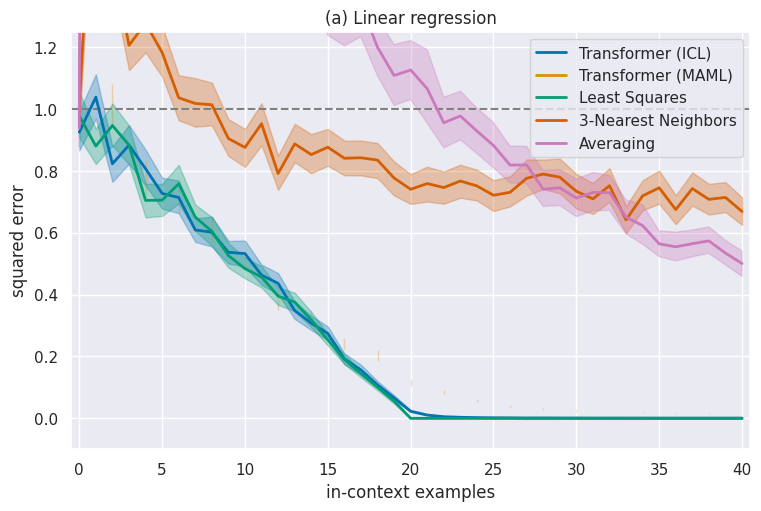

({'Transformer (ICL)': {'mean': [0.9250905036926269,
    1.038330364227295,
    0.8229291915893555,
    0.8831937789916993,
    0.8070541381835937,
    0.7270280361175537,
    0.7139287471771241,
    0.6089841842651367,
    0.6015645027160644,
    0.5367292881011962,
    0.5325091361999512,
    0.4628597259521484,
    0.4364222526550293,
    0.3483116865158081,
    0.3079838275909424,
    0.27433013916015625,
    0.19201492071151732,
    0.15619933605194092,
    0.10799511671066284,
    0.06616320610046386,
    0.022936329245567322,
    0.01055920124053955,
    0.005225907638669014,
    0.003322213888168335,
    0.0022619515657424927,
    0.0017259096726775169,
    0.0015175512060523033,
    0.0010795473121106625,
    0.001170293428003788,
    0.0009583165869116783,
    0.0009495022706687451,
    0.0007413506507873535,
    0.0007303913123905658,
    0.0007212303578853607,
    0.0007045463658869267,
    0.0006555011961609126,
    0.000626036524772644,
    0.000590697955340147,
    0.000

In [7]:
compute_and_plot_task_with_maml("linear_regression")


## Linear regression vectorized recompute

Use this as a focused check that the new vectorized MAML evaluator reproduces the linear-regression plot. This cell bypasses the MAML cache for linear regression only; the ICL transformer and baselines are still loaded from cache.


  loaded cached ICL/baseline curves: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559/metrics.json


1541c24b-e0c6-4c29-9dfe-49ff15e6e437:   0%|          | 0/1 [00:00<?, ?it/s]

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


1541c24b-e0c6-4c29-9dfe-49ff15e6e437: 100%|██████████| 1/1 [00:24<00:00, 24.81s/it]


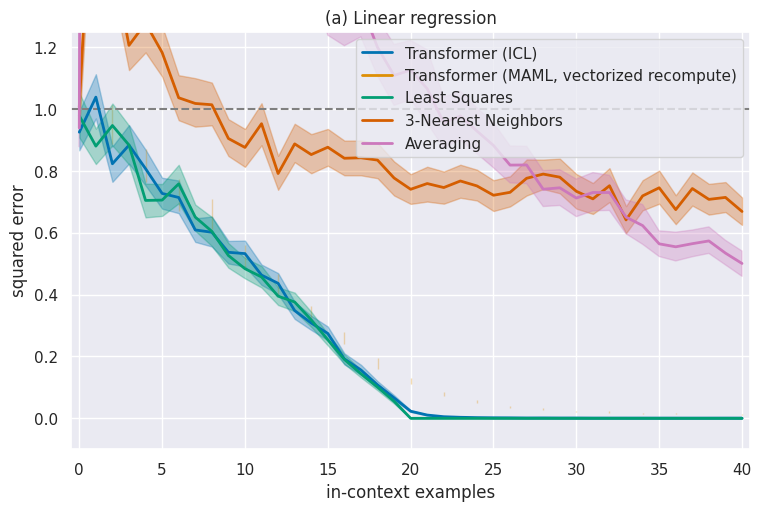

({'Transformer (ICL)': {'mean': [0.9250905036926269,
    1.038330364227295,
    0.8229291915893555,
    0.8831937789916993,
    0.8070541381835937,
    0.7270280361175537,
    0.7139287471771241,
    0.6089841842651367,
    0.6015645027160644,
    0.5367292881011962,
    0.5325091361999512,
    0.4628597259521484,
    0.4364222526550293,
    0.3483116865158081,
    0.3079838275909424,
    0.27433013916015625,
    0.19201492071151732,
    0.15619933605194092,
    0.10799511671066284,
    0.06616320610046386,
    0.022936329245567322,
    0.01055920124053955,
    0.005225907638669014,
    0.003322213888168335,
    0.0022619515657424927,
    0.0017259096726775169,
    0.0015175512060523033,
    0.0010795473121106625,
    0.001170293428003788,
    0.0009583165869116783,
    0.0009495022706687451,
    0.0007413506507873535,
    0.0007303913123905658,
    0.0007212303578853607,
    0.0007045463658869267,
    0.0006555011961609126,
    0.000626036524772644,
    0.000590697955340147,
    0.000

In [15]:
# Refresh the import chain in an already-running notebook kernel so `eval.py` uses
# the current vectorized implementation from `meta_eval.py`.
meta_eval_module = importlib.reload(meta_eval_module)
eval_module = importlib.reload(eval_module)
meta_plots = importlib.reload(meta_plots)
from plot_meta_paper_figure import get_task_metrics, plot_task

linear_cached_icl_metrics = load_cached_icl_metrics("linear_regression")
linear_vectorized_maml_metrics = get_task_metrics(
    run_paths["maml"]["linear_regression"],
    MAML_EVAL_NAME,
    cache=False,  # force recompute through the current vectorized code path
    transformer_label="Transformer (MAML, vectorized recompute)",
    skip_baselines=True,
    eval_kwargs_overrides=MAML_EVAL_OVERRIDES["linear_regression"],
)

linear_vectorized_metrics = {}
linear_vectorized_metrics.update(linear_cached_icl_metrics)
linear_vectorized_metrics.update(linear_vectorized_maml_metrics)

linear_vectorized_model_order = [
    "Transformer (ICL)",
    "Transformer (MAML)",
    "Transformer (MAML, vectorized recompute)",
    "Least Squares",
    "3-Nearest Neighbors",
    "Averaging",
]

# If the original MAML curve from the previous linear cell exists in memory, include
# it for direct visual comparison; otherwise this simply plots the recomputed curve.
if "linear_regression" in task_metrics and "Transformer (MAML)" in task_metrics["linear_regression"]:
    linear_vectorized_metrics["Transformer (MAML)"] = task_metrics["linear_regression"]["Transformer (MAML)"]

fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.0), constrained_layout=True)
plot_task(
    ax,
    "linear_regression",
    linear_vectorized_metrics,
    model_order=linear_vectorized_model_order,
)
figures["linear_regression_vectorized_recompute"] = fig
display(fig)
plt.close(fig)
linear_vectorized_metrics, fig


## Sparse linear regression



Task: (b) Sparse linear functions [sparse_linear_regression]
ICL transformer and baselines: cache only
Meta-learning transformer: MAML eval, baselines skipped
  loaded cached ICL/baseline curves: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/sparse_linear_regression/1bbcaa69-fe39-4335-abb2-28172861bf5a/metrics.json
  computing/loading meta-learning curve: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_sparse_linear_regression/8c5cff2f-cd47-4a9c-8228-afdb9596826b
  MAML eval overrides: {'batch_size': 64}


8c5cff2f-cd47-4a9c-8228-afdb9596826b:   0%|          | 0/1 [00:00<?, ?it/s]

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


8c5cff2f-cd47-4a9c-8228-afdb9596826b: 100%|██████████| 1/1 [00:23<00:00, 23.20s/it]

  curves available: ['Averaging', 'Lasso (alpha=0.01)', 'Least Squares', 'Transformer (ICL)', 'Transformer (MAML)']


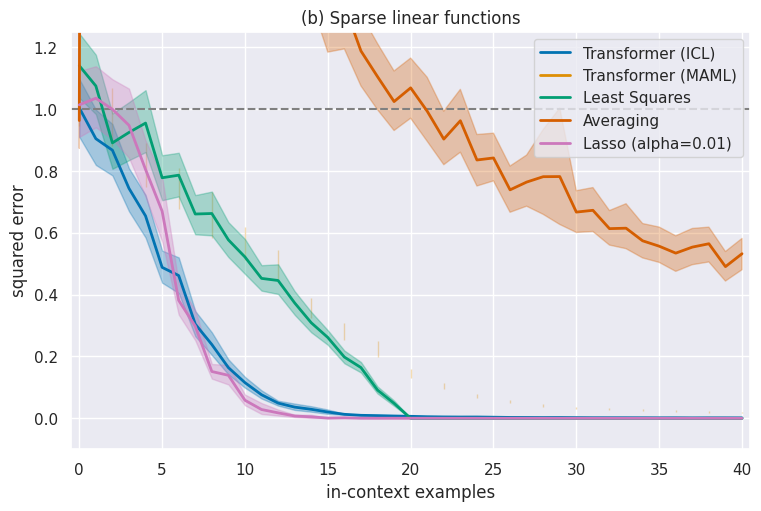

({'Transformer (ICL)': {'mean': [1.0036609967549641,
    0.9039658705393473,
    0.8667905330657959,
    0.7433226108551025,
    0.6542452971140543,
    0.4880240758260091,
    0.4615970452626546,
    0.304646372795105,
    0.23860649267832437,
    0.1638513207435608,
    0.11532184481620789,
    0.07619671026865642,
    0.04920023183027903,
    0.03617351005474726,
    0.0291330690185229,
    0.020345220963160198,
    0.012963241587082544,
    0.009702147915959358,
    0.008736360197265943,
    0.007490474730730057,
    0.0064672498653332395,
    0.005166844464838505,
    0.0044815633445978165,
    0.004173433718581994,
    0.0042359863097469015,
    0.0035881316289305687,
    0.0028742762903372445,
    0.0027260901406407356,
    0.0024783827054003873,
    0.0026179595539967218,
    0.002231033674130837,
    0.0019596085573236146,
    0.0019212982927759488,
    0.0018817369515697162,
    0.001806351977090041,
    0.0016446212927500408,
    0.001732632052153349,
    0.00144026040410002

In [16]:
compute_and_plot_task_with_maml("sparse_linear_regression")


## Decision trees



Task: (c) Decision trees [decision_tree]
ICL transformer and baselines: cache only
Meta-learning transformer: MAML eval, baselines skipped
  loaded cached ICL/baseline curves from source notebook output: MetaPaperPlotsPerTask.ipynb
  computing/loading meta-learning curve: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/032c4021-c5c7-49e8-b00d-4f9dd6ea898b
  MAML eval overrides: {'batch_size': 64}


032c4021-c5c7-49e8-b00d-4f9dd6ea898b:   0%|          | 0/1 [00:00<?, ?it/s]

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


032c4021-c5c7-49e8-b00d-4f9dd6ea898b: 100%|██████████| 1/1 [01:17<00:00, 77.92s/it]

  curves available: ['3-Nearest Neighbors', 'Greedy Tree Learning', 'Greedy Tree Learning\n(w/ sign preproc.)', 'Transformer (ICL)', 'Transformer (MAML)', 'XGBoost', 'XGBoost\n(w/ sign preproc.)']


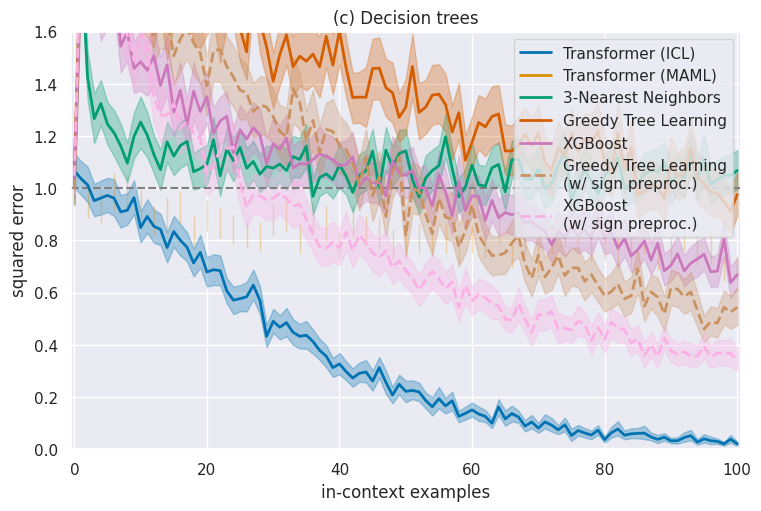

({'Transformer (ICL)': {'mean': [1.0667065382003784,
    1.037143349647522,
    1.0129938125610352,
    0.9524595141410828,
    0.9625266194343567,
    0.9726676940917969,
    0.9619248509407043,
    0.9096425771713257,
    0.9157028198242188,
    0.9640282392501831,
    0.849420428276062,
    0.8922370076179504,
    0.8544646501541138,
    0.8420241475105286,
    0.7730278968811035,
    0.8341466784477234,
    0.8007850646972656,
    0.7739654779434204,
    0.7137798070907593,
    0.754429280757904,
    0.6792235970497131,
    0.6877985000610352,
    0.684515655040741,
    0.6067046523094177,
    0.571330726146698,
    0.5769299268722534,
    0.5841747522354126,
    0.6288793683052063,
    0.5703425407409668,
    0.4330829977989197,
    0.4901501536369324,
    0.46754875779151917,
    0.4852294921875,
    0.4479209780693054,
    0.4326489567756653,
    0.43706703186035156,
    0.41303882002830505,
    0.3788558840751648,
    0.356977641582489,
    0.3126828074455261,
    0.32676017284

In [17]:
compute_and_plot_task_with_maml("decision_tree")


## ReLU 2-layer neural networks



Task: (d) 2-layer NN [relu_2nn_regression]
ICL transformer and baselines: cache only
Meta-learning transformer: MAML eval, baselines skipped
  loaded cached ICL/baseline curves: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/relu_2nn_regression/9f5157b6-5ca2-420d-a9fe-4dd30d619dda/metrics.json
  computing/loading meta-learning curve: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_relu_2nn_regression/a6e7479c-0345-44bf-97a3-ceeabfb48dc9
  MAML eval overrides: {'batch_size': 64}


a6e7479c-0345-44bf-97a3-ceeabfb48dc9:   0%|          | 0/1 [00:00<?, ?it/s]

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


a6e7479c-0345-44bf-97a3-ceeabfb48dc9: 100%|██████████| 1/1 [01:17<00:00, 77.28s/it]

  curves available: ['2-layer NN, GD', '3-Nearest Neighbors', 'Least Squares', 'Transformer (ICL)', 'Transformer (MAML)']


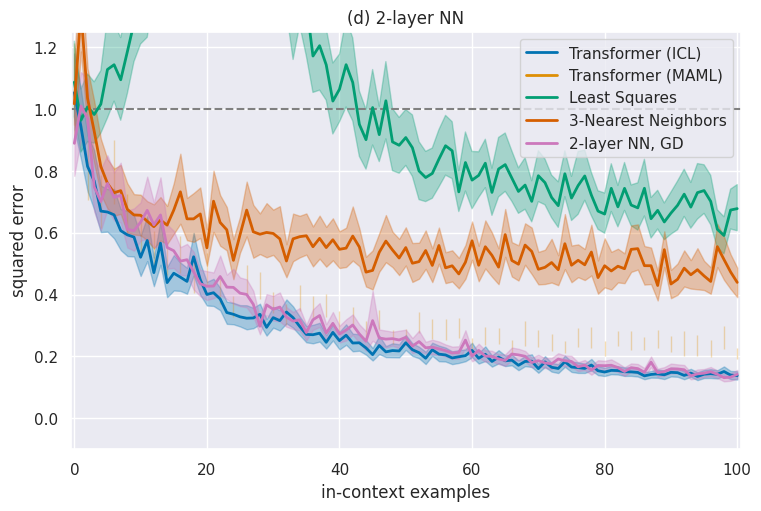

({'Transformer (ICL)': {'mean': [1.0528959035873413,
    0.9433128237724304,
    0.8142980337142944,
    0.7672244310379028,
    0.6699255108833313,
    0.6669487357139587,
    0.6578337550163269,
    0.6067352890968323,
    0.5931109189987183,
    0.5859368443489075,
    0.5206552743911743,
    0.5748838782310486,
    0.47104859352111816,
    0.5661706328392029,
    0.4387381970882416,
    0.46906614303588867,
    0.4562428593635559,
    0.4426446855068207,
    0.5222522020339966,
    0.4483739733695984,
    0.4004020094871521,
    0.4060594141483307,
    0.3858848810195923,
    0.34200090169906616,
    0.3363739848136902,
    0.32806187868118286,
    0.3236615061759949,
    0.32434728741645813,
    0.3362821936607361,
    0.29414233565330505,
    0.32546597719192505,
    0.3158417344093323,
    0.34375447034835815,
    0.32537445425987244,
    0.29711753129959106,
    0.2712392807006836,
    0.2702396810054779,
    0.2752268314361572,
    0.24577149748802185,
    0.27783530950546265,

In [18]:
compute_and_plot_task_with_maml("relu_2nn_regression")


## Save outputs


In [ ]:
output_dir = REPO_ROOT / "plots"
output_dir.mkdir(parents=True, exist_ok=True)

for task_name, fig in figures.items():
    png_path = output_dir / f"{task_name}_icl-{ICL_EVAL_NAME}_maml-{MAML_EVAL_NAME}.png"
    pdf_path = output_dir / f"{task_name}_icl-{ICL_EVAL_NAME}_maml-{MAML_EVAL_NAME}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)
